In [1]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def build_preprocessor(df):
    
    # target
    target = "Churn"
    
    # separate features
    X = df.drop(columns=[target])
    
    # identify columns
    cat_cols = X.select_dtypes(include="object").columns.tolist()
    num_cols = X.select_dtypes(exclude="object").columns.tolist()
    
    # remove ID if present
    if "customerID" in X.columns:
        cat_cols.remove("customerID")
        X = X.drop(columns=["customerID"])
    
    # transformers
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ]
    )
    
    return preprocessor, X

In [3]:
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, accuracy_score, precision_recall_curve,roc_curve

import matplotlib.pyplot as plt

df = pd.read_csv("../data/train.csv")
df = df.copy()

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

#Some feature engineering

df["tenure_group"] = pd.cut(df["tenure"], bins=[0,12,24,48,72]).astype(str)

services = [
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

df["num_services"] = df[services].apply(lambda x: (x == "Yes").sum(), axis=1)

df["high_charges"] = (df["MonthlyCharges"] > df["MonthlyCharges"].median()).astype(int)

df["contract_length"] = df["Contract"].map({
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
})

preprocessor, X = build_preprocessor(df)
y = df["Churn"]

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    pipe = Pipeline([
        ("pre", preprocessor),
        ("clf", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "f1", "roc_auc"],
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

results_df = pd.DataFrame(results).sort_values("CV ROC-AUC", ascending=False)
print(results_df)

                 Model  CV Accuracy     CV F1  CV ROC-AUC
0  Logistic Regression     0.746667  0.625361    0.845256
2              XGBoost     0.796444  0.575624    0.835508
1        Random Forest     0.783778  0.535857    0.822263


In [6]:
for name, model in models.items():
    pipe = Pipeline([
        ("pre", preprocessor),
        ("clf", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_val)
    y_prob = pipe.predict_proba(X_val)[:, 1]

    print(f"\n===== {name} =====")
    print("Accuracy :", accuracy_score(y_val, y_pred))
    print("F1 Score :", f1_score(y_val, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_val, y_prob))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_val, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))


===== Logistic Regression =====
Accuracy : 0.7309058614564832
F1 Score : 0.6130268199233716
ROC-AUC  : 0.8433876727341845

Confusion Matrix:
[[583 244]
 [ 59 240]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.70      0.79       827
           1       0.50      0.80      0.61       299

    accuracy                           0.73      1126
   macro avg       0.70      0.75      0.70      1126
weighted avg       0.80      0.73      0.75      1126


===== Random Forest =====
Accuracy : 0.7868561278863233
F1 Score : 0.5471698113207547
ROC-AUC  : 0.8292171001281984

Confusion Matrix:
[[741  86]
 [154 145]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       827
           1       0.63      0.48      0.55       299

    accuracy                           0.79      1126
   macro avg       0.73      0.69      0.70      1126
weighted avg       0.77      

Given the class imbalance and the importance of identifying churners, models were further evaluated using precision–recall curves. This allows comparison across all decision thresholds and enables selection of an operating point that balances recall and precision based on business requirements.

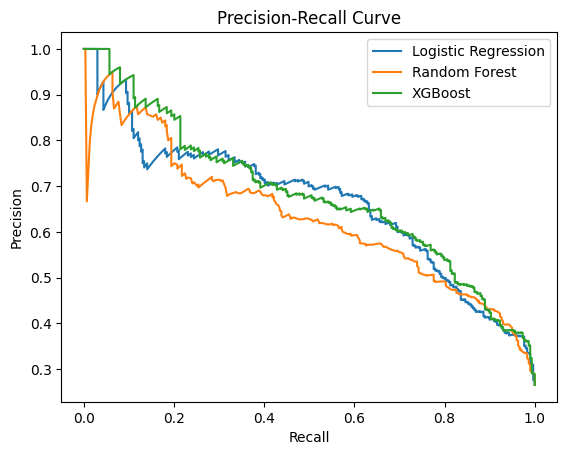

In [7]:
for name, model in models.items():
    pipe = Pipeline([
        ("pre", preprocessor),
        ("clf", model)
    ])

    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_val)[:, 1]

    precision, recall, _ = precision_recall_curve(y_val, y_prob)

    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

The precision–recall curves show that model performance varies across recall levels. XGBoost achieves higher precision than the other models across most of the recall range, particularly in the mid-to-high recall region (≈0.6–0.9), indicating better ability to identify churners while controlling false positives.

Logistic Regression performs competitively and slightly outperforms XGBoost in parts of the mid-recall region, but is generally marginally lower at higher recall levels. Random Forest consistently underperforms both models across the curve.

At very high recall levels (approaching 1.0), all models exhibit a sharp decline in precision and converge to similar performance, which is expected as more predictions are forced into the positive class.

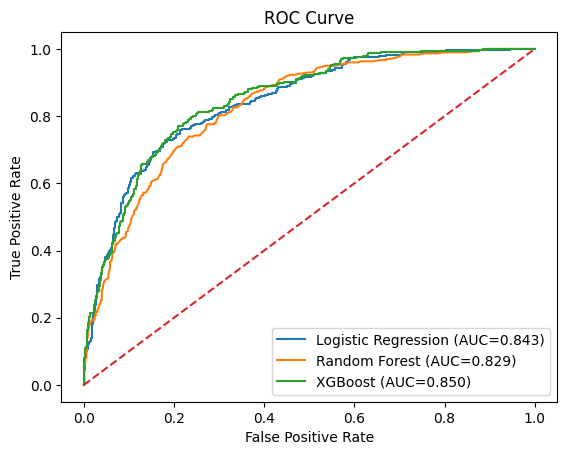

In [8]:
for name, model in models.items():
    pipe = Pipeline([
        ("pre", preprocessor),
        ("clf", model)
    ])

    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_val)[:, 1]

    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc = roc_auc_score(y_val, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

ROC curve analysis shows that XGBoost achieves the highest AUC (0.850), closely followed by Logistic Regression (0.843), with Random Forest trailing. The small difference between Logistic Regression and XGBoost suggests comparable overall ranking ability, with both models effectively separating churners from non-churners.

However, the differences between Logistic Regression and XGBoost are relatively small, indicating comparable overall performance. In contrast, Random Forest consistently underperforms both models.

While ROC-AUC provides a useful measure of overall separability, it does not fully capture performance on the minority churn class. As such, precision–recall analysis remains more informative for model selection in this imbalanced setting.

## Final Model Selection

Model selection was based on cross-validation performance, precision–recall analysis, ROC-AUC, and final test set evaluation to ensure robustness under class imbalance and alignment with the objective of identifying churners.

Logistic Regression demonstrates strong overall performance, achieving the highest cross-validation ROC-AUC (0.845) and the best F1-score among the models, indicating a balanced handling of both classes. On the test set, it achieves a high recall of 0.80 for the churn class, successfully identifying the majority of at-risk customers, which is critical in churn prediction tasks.

While XGBoost achieves the highest ROC-AUC (0.850) and overall accuracy on the test set, its recall for the churn class (0.55) is substantially lower than that of Logistic Regression, indicating that it misses a larger proportion of churners. Random Forest further underperforms in this regard, with even lower recall (0.48), despite higher accuracy driven by correct classification of the majority class.

Precision–recall analysis shows that XGBoost provides slightly higher precision in the high-recall region; however, Logistic Regression remains competitive across the curve and, at the default operating threshold, achieves significantly higher recall. Given that the primary objective is to minimize false negatives (i.e., avoid missing churners), this behavior is preferable.

Therefore, Logistic Regression is selected as the final model, as it offers the best trade-off for this problem by prioritizing churn detection while maintaining strong overall performance. Additionally, its interpretability allows for direct understanding of feature effects, enabling actionable business insights and making it particularly suitable for deployment in a customer retention context.